<a href="https://colab.research.google.com/github/pradeepK1812/New-Rust-Repo/blob/Rust/Binomial_vs_Normal_Distribution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


--- Distribution Comparison (N=400, P=0.5) ---
Approximation Check (Mean/SD):
  Mean (μ) = 200.00
  Standard Deviation (σ) = 10.00

Probability of getting 190 to 230 Heads:
  Exact Binomial Probability: 85.2022%
  Normal Approximation Probability: 85.1997% (Using Continuity Correction)


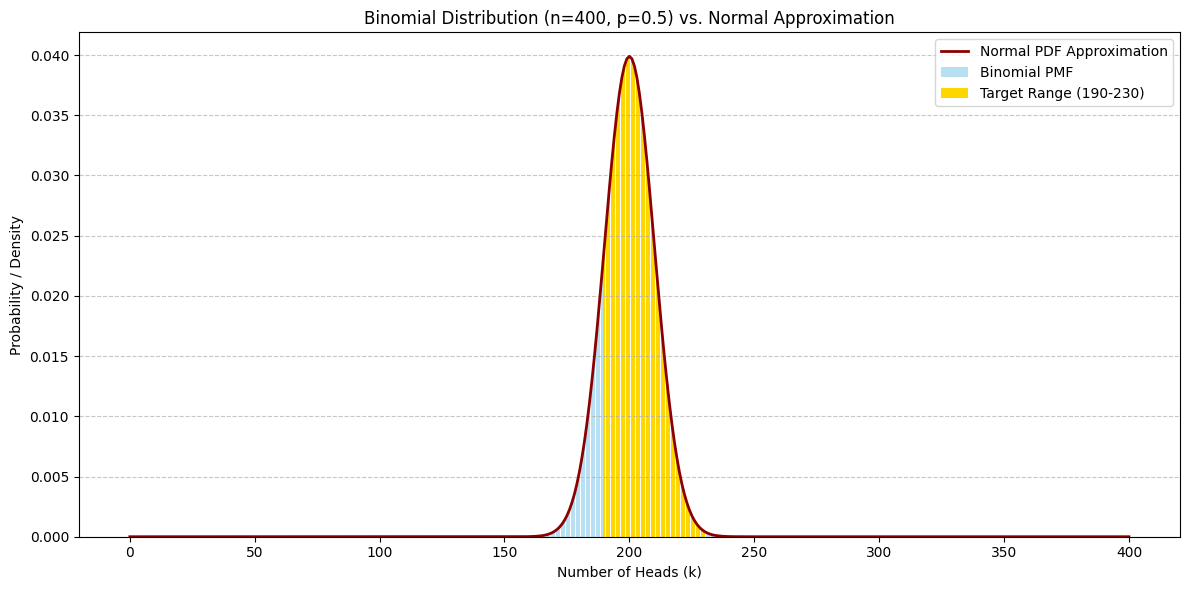

In [2]:
import argparse
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom, norm

def calculate_probabilities(n_flips, p_head=0.5):
    """
    Calculates the exact binomial probability and the normal approximation
    for getting between 190 and 230 heads.

    Args:
        n_flips (int): The total number of coin flips (trials).
        p_head (float): The probability of getting a head on a single flip.

    Returns:
        tuple: (binomial_prob, normal_prob, mean, std_dev)
    """
    # --- Binomial Distribution Parameters ---
    n = n_flips
    p = p_head

    # 1. Exact Binomial Probability P(190 <= X <= 230)
    # P(a <= X <= b) = CDF(b) - CDF(a-1)

    lower_bound = 190
    upper_bound = 230

    # Ensure bounds are valid
    if lower_bound > n or upper_bound < 0:
        return 0, 0, 0, 0

    # CDF(230) - CDF(189)
    binomial_prob = binom.cdf(upper_bound, n, p) - binom.cdf(lower_bound - 1, n, p)

    # --- Normal Approximation Parameters ---
    # Mean (mu) = n * p
    mean = n * p
    # Standard Deviation (sigma) = sqrt(n * p * (1 - p))
    std_dev = np.sqrt(n * p * (1 - p))

    # 2. Normal Approximation Probability using Continuity Correction
    # P(190 <= X <= 230) approx P(189.5 <= Y <= 230.5)

    z_lower = (lower_bound - 0.5 - mean) / std_dev
    z_upper = (upper_bound + 0.5 - mean) / std_dev

    # Calculate probability using the Normal CDF (Standard Normal - Z-score)
    normal_prob = norm.cdf(z_upper) - norm.cdf(z_lower)

    return binomial_prob, normal_prob, mean, std_dev

def plot_distributions(n_flips, mean, std_dev, p_head=0.5):
    """
    Generates a plot comparing the Binomial PMF and the Normal PDF.
    """
    n = n_flips
    p = p_head

    # The range of possible number of heads (0 to n)
    k = np.arange(0, n + 1)

    # 1. Binomial Distribution (PMF - Probability Mass Function)
    binomial_pmf = binom.pmf(k, n, p)

    # 2. Normal Distribution (PDF - Probability Density Function)
    # Using the same range k for the x-axis, calculate the PDF
    normal_pdf = norm.pdf(k, mean, std_dev)

    # --- Plotting ---
    plt.figure(figsize=(12, 6))

    # Plot Binomial Distribution (Discrete bars)
    plt.bar(k, binomial_pmf, color='skyblue', alpha=0.6, label='Binomial PMF')

    # Plot Normal Distribution (Continuous line)
    plt.plot(k, normal_pdf, color='darkred', linewidth=2, label='Normal PDF Approximation')

    # Highlight the target range (190 to 230 heads)
    highlight_range = np.arange(190, 231)
    highlight_pmf = binom.pmf(highlight_range, n, p)
    plt.bar(highlight_range, highlight_pmf, color='gold', alpha=1.0, label='Target Range (190-230)')

    plt.title(f'Binomial Distribution (n={n}, p={p}) vs. Normal Approximation')
    plt.xlabel('Number of Heads (k)')
    plt.ylabel('Probability / Density')
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

def main():
    """
    Main function to parse command-line arguments and run the comparison.
    Handles extra arguments passed by Jupyter/Colab kernels.
    """
    parser = argparse.ArgumentParser(
        description="Compare Binomial and Normal Distributions for coin flips.",
        formatter_class=argparse.RawTextHelpFormatter
    )

    parser.add_argument(
        '--n_flips',
        type=int,
        default=400,
        help="Number of coin flips (trials). Default is 400."
    )

    # FIX: Use parse_known_args() to safely ignore arguments like -f
    # that are automatically passed by the Colab/Jupyter kernel.
    args, unknown = parser.parse_known_args()
    n_flips = args.n_flips

    if n_flips <= 0:
        print("Error: The number of flips must be a positive integer.")
        return

    # Check for Normal Approximation requirement (n*p >= 5 and n*(1-p) >= 5)
    if n_flips * 0.5 < 5:
        print(f"Warning: n={n_flips} is too small for a good Normal approximation (requires np >= 5).")

    binomial_prob, normal_prob, mean, std_dev = calculate_probabilities(n_flips)

    print(f"\n--- Distribution Comparison (N={n_flips}, P=0.5) ---")
    print(f"Approximation Check (Mean/SD):")
    print(f"  Mean (μ) = {mean:.2f}")
    print(f"  Standard Deviation (σ) = {std_dev:.2f}")

    print("\nProbability of getting 190 to 230 Heads:")
    print(f"  Exact Binomial Probability: {binomial_prob * 100:.4f}%")
    print(f"  Normal Approximation Probability: {normal_prob * 100:.4f}% (Using Continuity Correction)")

    plot_distributions(n_flips, mean, std_dev)

if __name__ == '__main__':
    main()

In [3]:
x = 2
print("x =", x)
print("float(x) =", float(x))
print("x still has type", type(x))
print("Overwriting x.")
x = float(x)
print("Now, x has type", type(x))
numstring = "3.1415926"
y = float(numstring)
print("y has type", type(y))
best_number = 73
x = str(best_number)
print("x has type", type(x))
thisworks = float("inf")
print("float(\'inf\') has type", type(thisworks))
infinity_plus_one = float('inf') + 1

x = 2
float(x) = 2.0
x still has type <class 'int'>
Overwriting x.
Now, x has type <class 'float'>
y has type <class 'float'>
x has type <class 'str'>
float('inf') has type <class 'float'>


In [4]:
s = "Hello, "
t = "World."
u = s + t
print(type(u))
print(u)
print(u[9])

<class 'str'>
Hello, World.
r


<class 'list'>
The first item is 1
The second item is 2
The last item is 100
The second to last item is 6
<svg baseProfile="full" height="60" version="1.1" width="600" xmlns="http://www.w3.org/2000/svg" xmlns:ev="http://www.w3.org/2001/xml-events" xmlns:xlink="http://www.w3.org/1999/xlink"><defs /><path d="M5.000000 5.000000 L5.000000 5.000000 L22.000000 5.000000 L22.000000 35.000000 L5.000000 35.000000 Z" fill="#ffffff" stroke="#000000" stroke-width="2" /><text dominant-baseline="central" fill="#000000" font-family="monospace" font-size="24" font-weight="normal" stroke="#000000" text-anchor="middle" x="13.5" y="20.0">1</text><path d="M22.000000 5.000000 L22.000000 5.000000 L39.000000 5.000000 L39.000000 35.000000 L22.000000 35.000000 Z" fill="#ffffff" stroke="#000000" stroke-width="2" /><text dominant-baseline="central" fill="#000000" font-family="monospace" font-size="24" font-weight="normal" stroke="#000000" text-anchor="middle" x="30.5" y="20.0">2</text><path d="M39.000000 5.000000

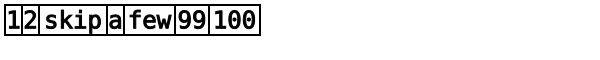

In [15]:
!pip  install  ds2
!pip install ds2viz
!mkdir -p ../figures
import ds2
from IPython.display import Image, SVG, display
ds2.figs.OUTPUT_DIR = "."
L = [1,2,3,4,5,6]
print(type(L))
L.append(100)
print("The first item is", L[0])
print("The second item is", L[1])
print("The last item is", L[-1])
print("The second to last item is", L[-2])
L[2] = 'skip'
L[3] = 'a'
L[4] = 'few'
L[-2] = 99
from ds2.figs import drawlist
drawlist(L, 'list03')
display(SVG(filename="../figures/list03.svg"))
